In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
train = pd.read_csv("../data/train.csv", converters={"bbox": ast.literal_eval})
test = pd.read_csv("../data/test.csv",  converters={"bbox": ast.literal_eval})

In [3]:
train

,row_id,image_id,width,height,bbox,class_id
0,train_00000001_0000,00000001.jpg,1920,1080,"[967.5, 331.5, 463.0, 447.0]",3
1,train_00000001_0001,00000001.jpg,1920,1080,"[724.5, 336.5, 324.0, 412.0]",3
2,train_00000001_0002,00000001.jpg,1920,1080,"[430.5, 390.5, 249.0, 457.0]",4
3,train_00000001_0003,00000001.jpg,1920,1080,"[1199.0, 5.5, 208.0, 282.0]",3
4,train_00000001_0004,00000001.jpg,1920,1080,"[980.0, 5.5, 273.0, 285.0]",3
...,...,...,...,...,...,...
16057,train_00002164_0005,00002164.jpg,1280,720,"[594.4, 566.5, 390.0, 146.0]",4
16058,train_00002164_0006,00002164.jpg,1280,720,"[792.5, 1.0, 147.0, 321.0]",3
16059,train_00002164_0007,00002164.jpg,1280,720,"[187.0, 132.0, 168.0, 255.0]",3
16060,train_00002164_0008,00002164.jpg,1280,720,"[55.0, 180.5, 107.0, 198.0]",3


In [4]:
x = [value["bbox"][0]* 1280 / value["width"] for i, value in train.iterrows()]
y = [value["bbox"][1]* 720 / value["height"] for i, value in train.iterrows()]


<Axes: >

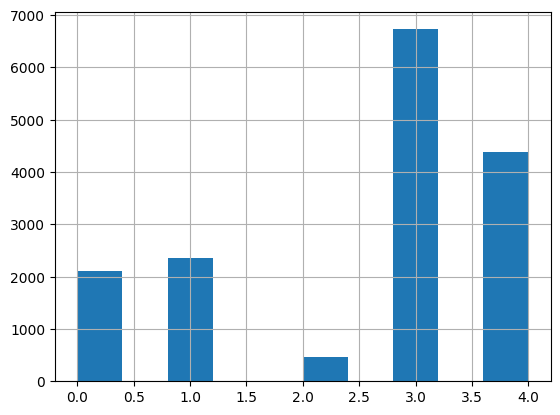

In [5]:
train["class_id"].hist()

(array([[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  11.,  15.,   6.,
           8.,  14.,  12.,  15.,  20.,  23.,  33.,  38.,  21.,  21.,   9.,
           9.,  14.,  13.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   1.,   0.,   7.,  22.,  33.,  35.,  34.,
          13.,   9.,   8.,   6.,   8.,  13.,  32.,  12.,  10.,   6.,  14.,
           8.,  22.,  28.,   1.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,  12.,  28.,  47.,  28.,  60.,  33.,  22.,
          30.,  14.,  17.,  30.,  14.,  11.,  13.,   5.,  11.,   4.,   4.,
           2.,  13.,  31.,   2.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   1.,   3.,  39.,  58.,  81.,  80.,  54.,  27.,  22.,
          33.,  32.,  32.,  37.,  36.,  40.,  26.,  24.,  13.,  11.,  16.,
           2.,   7.,  14.,   2.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   3.,   4.,  13.,  21., 144.,  50.,  21.,  20.,  17.,
          18.,  26.,  68.,   9.,  30.,  54.,  25.,  26.,  33.,  34.,  21.,
          15.,   7

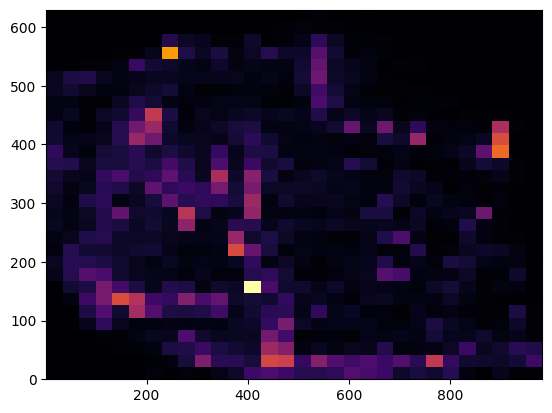

In [6]:
plt.hist2d(x, y, bins=30, cmap="inferno")

In [7]:
newx = np.array(x)
newy = np.array(y)

In [8]:
newx[train["class_id"] == 0]

array([377.        , 432.4       , 432.66666667, ..., 576.        ,
       470.        , 455.        ])

(array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  4.,  0.,  0.,  0.,
          0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1., 10.,  1.,  0.,
          0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
          0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  1.,  8.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  1.,  7., 14.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0., 20.,  1.,  1.,  0.,  0.,  0.,  0.,
          2.,  2.,  4.,  4.,  5.,  2.,  1.,  3.,  2.,  1.,  7.,  3.,  6.,
          0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  1.,
          3.,  3.,  4.,  8., 17.,  9., 23.,  8.,  3.,  1.,  1.,  0.,  0.,
          0.,  0.,  0.,  0.],
        [ 0.,  0.,  3.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,
          5.,  1., 14.,  4.,  0.,  4

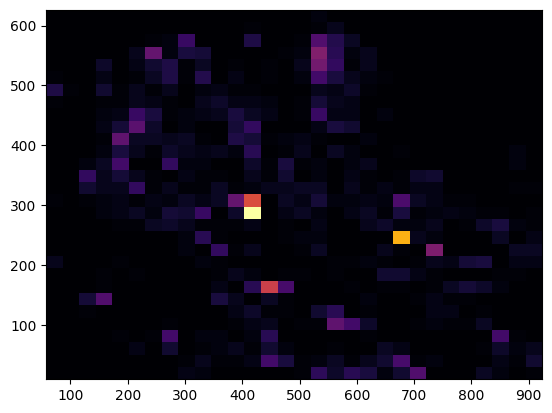

In [9]:
plt.hist2d(newx[train["class_id"] == 0], newy[train["class_id"] == 0], bins=30, cmap="inferno")

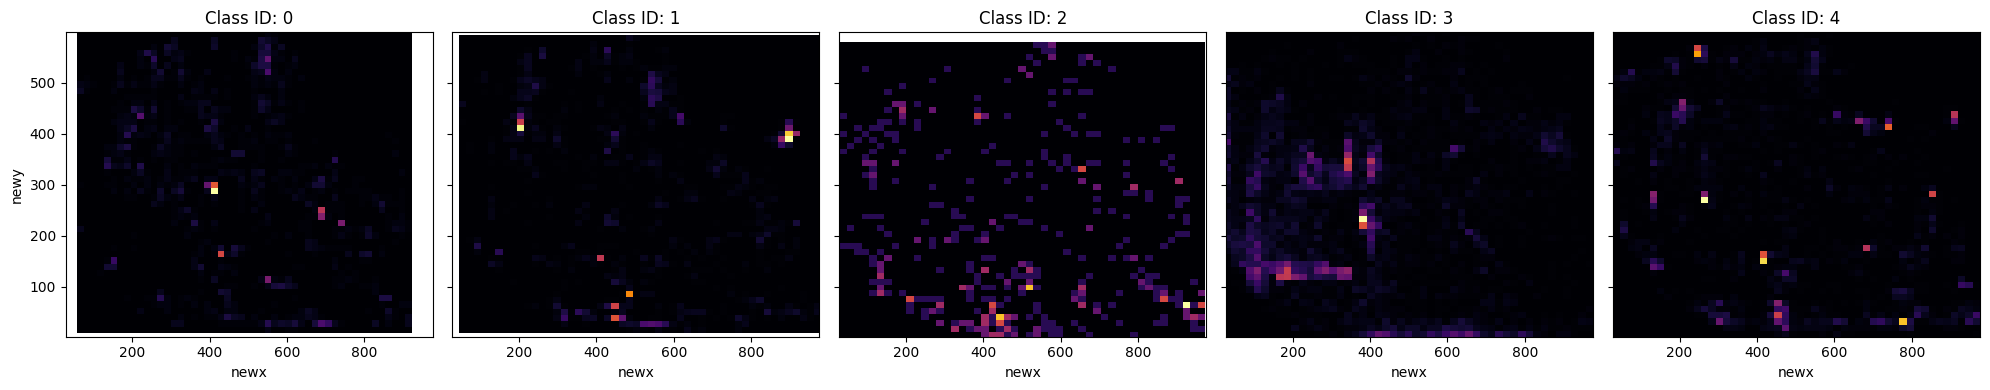

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)
for i in range(5):
    # Create the boolean mask for the current class_id
    mask = train["class_id"] == i
    
    # Plot on the specific subplot axis
    axes[i].hist2d(
        newx[mask], 
        newy[mask], 
        bins=50, 
        cmap="inferno"
    )
    
    # Formatting
    axes[i].set_title(f"Class ID: {i}")
    axes[i].set_xlabel("newx")
    if i == 0:
        axes[i].set_ylabel("newy")

plt.tight_layout()

# Split train, test, validation data

In [15]:
train_df, temp_df = train_test_split(train, test_size=0.3, random_state=42, stratify=train["class_id"])

In [18]:
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["class_id"])

In [20]:
train_df.to_csv("../data/split/train.csv")
test_df.to_csv("../data/split/test.csv")
val_df.to_csv("../data/split/val.csv")

In [23]:
val_df["class_id"].value_counts()

class_id
3    1009
4     658
1     354
0     317
2      71
Name: count, dtype: int64

In [27]:
1 / train_df["class_id"].value_counts() 

class_id
3    0.000212
4    0.000325
1    0.000605
0    0.000676
2    0.003049
Name: count, dtype: float64

In [28]:
1 / train["class_id"].value_counts() 

class_id
3    0.000149
4    0.000228
1    0.000424
0    0.000473
2    0.002132
Name: count, dtype: float64